# Amish cohort → AnnData

Patient-derived lines from an Amish cohort ([`cpg0047`](https://broadinstitute.github.io/cellpainting-gallery/)), varying cell line, seeding density and timepoint. The design covariates make this a clean test of what an embedding actually encodes.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0047-amish/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0047-amish/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
print(f"{len(files)} plates")

3 plates


In [3]:
adata = cpio.read_profiles(files, index_columns=["Plate", "Well"], on_column_mismatch="intersect")
adata

AnnData object with n_obs × n_vars = 468 × 794
    obs: 'plate_map_name', 'cell_line', 'density_cells_per_well', 'timepoint_hours', 'Unnamed: 5', 'Unnamed: 6', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "cell_line", "density_cells_per_well", "timepoint_hours", "plate_map_name"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Image_Granularity_10_AGP,image,granularity,agp,NaN,1
Image_Granularity_10_Brightfield,image,granularity,brightfield,NaN,1
Image_Granularity_10_DNA,image,granularity,dna,NaN,1
Image_Granularity_10_ER,image,granularity,er,NaN,1
Image_Granularity_10_Mito,image,granularity,mito,NaN,1
...,...,...,...,...,...
Nuclei_Texture_InverseDifferenceMoment_DNA_3_00_256,nuclei,texture,dna,NaN,1
Nuclei_Texture_InverseDifferenceMoment_Mito_3_02_256,nuclei,texture,mito,NaN,1
Nuclei_Texture_InverseDifferenceMoment_RNA_10_01_256,nuclei,texture,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["cell_line", "density_cells_per_well", "timepoint_hours"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

468 wells x 790 features
non-finite: 0 | max|x|: 2019.4

cell_line:
cell_line
36_(Affected)_-_GM06016    25
(1)_GM05889                12
(10)_GM05915               12
(11)_GM05928               12
(12)_GM05930               12
(13)_GM05936               12

density_cells_per_well:
density_cells_per_well
250     156
500     156
1000    156

timepoint_hours:
timepoint_hours
144    432
120     36


In [6]:
adata.write_h5ad(PROFILES.parent / "amish.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "cell_line", "density_cells_per_well", "timepoint_hours"]))

,observed,baseline,ratio
covariate,,,
Plate,0.703,0.432,1.628
cell_line,0.244,0.027,9.024
density_cells_per_well,0.488,0.333,1.463
timepoint_hours,0.901,0.858,1.050


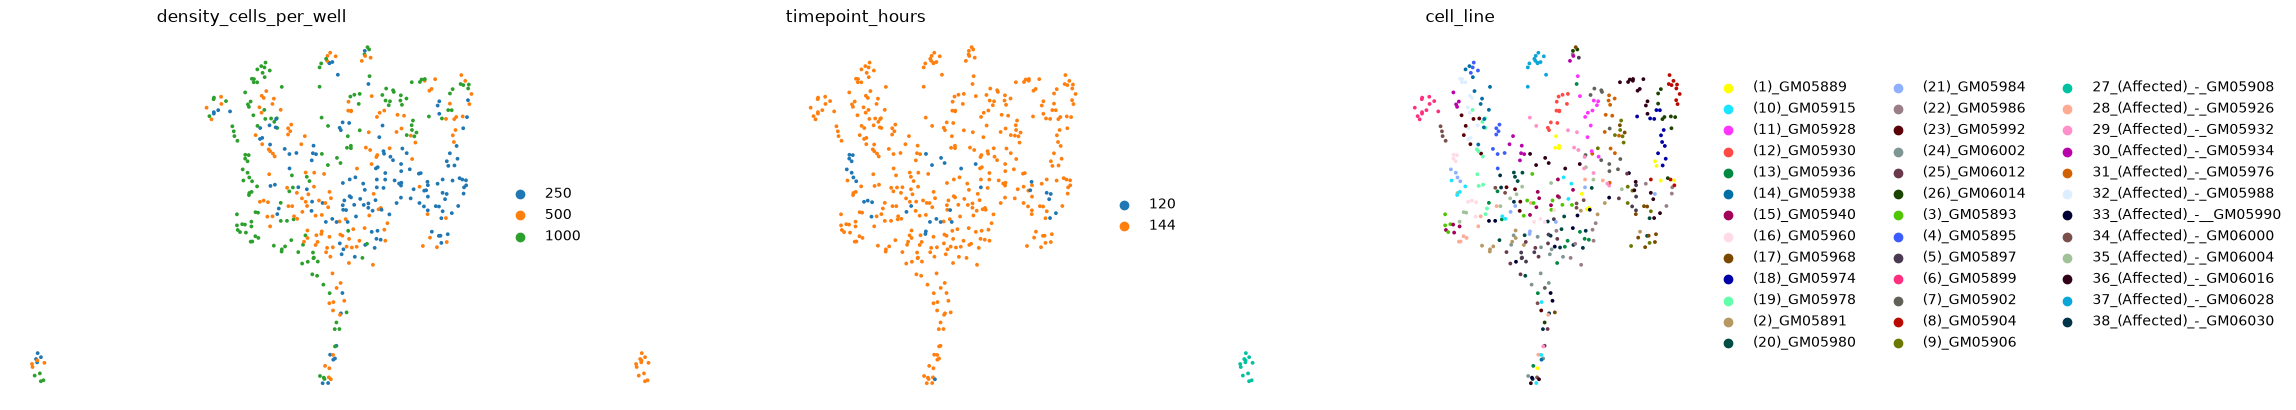

In [9]:
sc.pl.umap(
    adata,
    color=present(["density_cells_per_well", "timepoint_hours", "cell_line", "Plate"])[:3],
    ncols=3,
    frameon=False,
    size=30,
)